In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import pearsonr

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
csv_folder = "../datasets/csv_files"

for file in os.listdir(csv_folder):
    if file.endswith(".csv"):
        df_name = os.path.splitext(file)[0]  # filename without .csv
        file_path = os.path.join(csv_folder, file)

        globals()[df_name] = pd.read_csv(file_path)

## **What Drives Customer Retention in GoodCabs?**

<div style="background:#EBE1FF;
padding:12px;
border-radius:8px;
border-left:6px solid #8C52FF;">

<strong>Research Question 1</strong>

Do cities with higher driver ratings have higher repeat passenger rates?

</div>

In [3]:
passenger_summary = fact_passenger_summary.copy()
city = dim_city.copy()
passenger_summary = pd.merge(passenger_summary,city,on="city_id",how="inner")
passenger_summary["month"] = pd.to_datetime(passenger_summary["month"])
passenger_summary["month"] = passenger_summary.month.dt.month_name()
passenger_summary_agg = passenger_summary.groupby(["city_name"]).agg(
    total_passengers = ("total_passengers","sum"),
    repeat_passengers = ("repeat_passengers","sum")
).reset_index()
passenger_summary_agg["rpr"] = round(passenger_summary_agg["repeat_passengers"] / passenger_summary_agg["total_passengers"]*100,2)

In [4]:
trips = fact_trips.copy()
city = dim_city.copy()
trips = pd.merge(trips,city,on="city_id",how="inner")

In [5]:
city_wise_avg_driver_rating = trips.groupby(["city_name"]).agg(
    avg_driver_rating = ("driver_rating","mean")
).round(1).reset_index()

In [6]:
rating_rpr = pd.merge(passenger_summary_agg,city_wise_avg_driver_rating,on="city_name",how="inner")

In [7]:
corr, p_value = pearsonr(
    rating_rpr['avg_driver_rating'],
    rating_rpr['rpr']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.7564290281153278
P-value: 0.011338670950622132


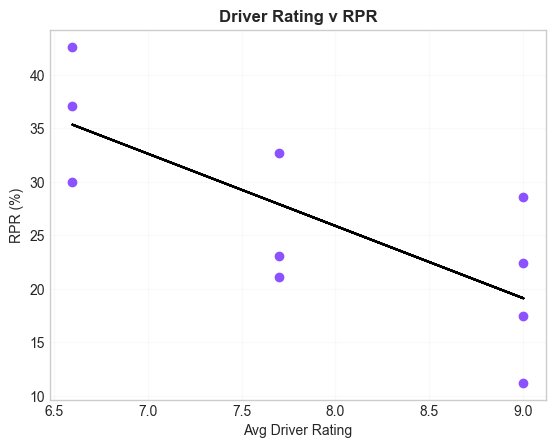

In [8]:
x = rating_rpr['avg_driver_rating']
y = rating_rpr['rpr']

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y, color='#8C52FF')
plt.plot(x, m*x + b, color='black')
plt.title('Driver Rating v RPR',fontweight="bold")
plt.xlabel("Avg Driver Rating")
plt.ylabel("RPR (%)")
plt.grid(alpha=0.1)
plt.show()

<div style="background:#EBE1FF;
padding:12px;
border-radius:8px;
border-left:6px solid #8C52FF;">

<strong>Research Question 2</strong>

Does fare influence retention?

</div>

In [9]:
city_wise_avg_fare = trips.groupby(["city_name"]).agg(
    avg_fare = ("fare_amount","mean")
).round(1).reset_index()

In [10]:
fare_rpr = pd.merge(passenger_summary_agg,city_wise_avg_fare,on="city_name",how="inner")

In [11]:
corr, p_value = pearsonr(
    fare_rpr['avg_fare'],
    fare_rpr['rpr']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.6542989912209133
P-value: 0.040113467387727364


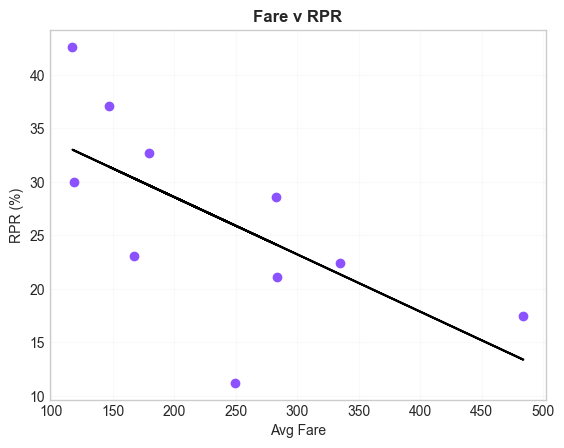

In [12]:
x = fare_rpr['avg_fare']
y = fare_rpr['rpr']

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y, color='#8C52FF')
plt.plot(x, m*x + b, color='black')
plt.title('Fare v RPR',fontweight="bold")
plt.xlabel("Avg Fare")
plt.ylabel("RPR (%)")
plt.grid(alpha=0.1)
plt.show()

<div style="background:#EBE1FF;
padding:12px;
border-radius:8px;
border-left:6px solid #8C52FF;">

<strong>Research Question 3</strong>

Does distance influence retention?

</div>

In [13]:
city_wise_avg_distance = trips.groupby(["city_name"]).agg(
    avg_distance = ("distance_travelled(km)","mean")
).round(1).reset_index()

In [14]:
distance_rpr = pd.merge(passenger_summary_agg,city_wise_avg_distance,on="city_name",how="inner")

In [15]:
corr, p_value = pearsonr(
    distance_rpr['avg_distance'],
    distance_rpr['rpr']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.5985961280120558
P-value: 0.06749621804295085


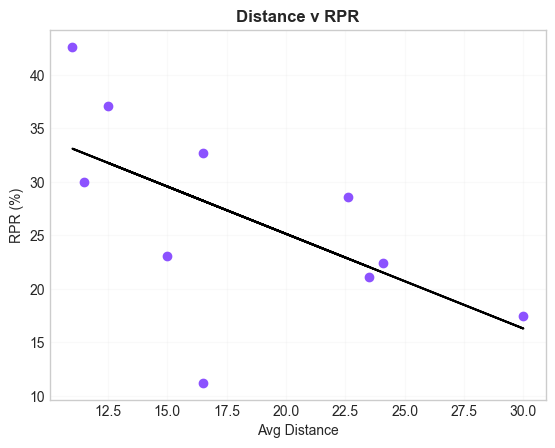

In [16]:
x = distance_rpr['avg_distance']
y = distance_rpr['rpr']

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y, color='#8C52FF')
plt.plot(x, m*x + b, color='black')
plt.title('Distance v RPR',fontweight="bold")
plt.xlabel("Avg Distance")
plt.ylabel("RPR (%)")
plt.grid(alpha=0.1)
plt.show()

Why do Lucknow and Surat have the highest retention despite having some of the lowest driver ratings?

In [17]:
high_rpr_cities = passenger_summary_agg.sort_values("rpr",ascending=False).head(3)
bottom_rpr_cities = passenger_summary_agg.sort_values("rpr",ascending=False).tail(3)
high_low_rpr_cities = pd.concat([high_rpr_cities,bottom_rpr_cities],ignore_index=True)


In [18]:
city_wise_trip_summary = trips.groupby(["city_name"]).agg(
    avg_distance = ("distance_travelled(km)","mean"),
    avg_fare = ("fare_amount","mean"),
    avg_driver_rating = ("driver_rating","mean")
).round(1).reset_index()

In [19]:
high_low_rpr_city_wise_trip_summary = pd.merge(high_low_rpr_cities,city_wise_trip_summary,on="city_name",how="inner")
high_low_rpr_city_wise_trip_summary

,city_name,total_passengers,repeat_passengers,rpr,avg_distance,avg_fare,avg_driver_rating
0,Surat,20264,8638,42.63,11.0,117.3,6.6
1,Lucknow,25857,9597,37.12,12.5,147.2,6.6
2,Indore,22079,7216,32.68,16.5,179.8,7.7
3,Chandigarh,23978,5070,21.14,23.5,283.7,7.7
4,Jaipur,55538,9682,17.43,30.0,483.9,9.0
5,Mysore,13158,1477,11.23,16.5,249.7,9.0


In [20]:
repeat_passenger_distribution = dim_repeat_trip_distribution.copy()
total_repeat_passengers = repeat_passenger_distribution.groupby(["city_id"]).agg(
    total_repeat_passengers = ("repeat_passenger_count","sum")
)

In [21]:
repeat_passenger_distribution = dim_repeat_trip_distribution[dim_repeat_trip_distribution["trip_count"] >= "5-Trips"]
repeat_passengers_with_more_than_5_trips = repeat_passenger_distribution.groupby(["city_id"]).agg(
    repeat_passengers_with_more_than_5_trips = ("repeat_passenger_count","sum")
)

In [22]:
repeat_passenger_summary = pd.merge(total_repeat_passengers,repeat_passengers_with_more_than_5_trips,on="city_id",how="inner")
repeat_passenger_summary["pct_repeat_passengers_with_more_than_5_trips"] = round((repeat_passenger_summary["repeat_passengers_with_more_than_5_trips"] / repeat_passenger_summary["total_repeat_passengers"])*100,2)
repeat_passenger_summary
city = dim_city.copy()
repeat_passenger_summary = pd.merge(repeat_passenger_summary,city,on="city_id",how="inner")
repeat_passenger_summary = repeat_passenger_summary[["city_name","pct_repeat_passengers_with_more_than_5_trips"]]

In [23]:
high_low_rpr_city_wise_trip_summary = pd.merge(high_low_rpr_city_wise_trip_summary,repeat_passenger_summary,on="city_name",how="inner")
high_low_rpr_city_wise_trip_summary

,city_name,total_passengers,repeat_passengers,rpr,avg_distance,avg_fare,avg_driver_rating,pct_repeat_passengers_with_more_than_5_trips
0,Surat,20264,8638,42.63,11.0,117.3,6.6,58.07
1,Lucknow,25857,9597,37.12,12.5,147.2,6.6,58.27
2,Indore,22079,7216,32.68,16.5,179.8,7.7,28.06
3,Chandigarh,23978,5070,21.14,23.5,283.7,7.7,30.91
4,Jaipur,55538,9682,17.43,30.0,483.9,9.0,16.04
5,Mysore,13158,1477,11.23,16.5,249.7,9.0,13.61


In [24]:
trips = fact_trips.copy()
city = dim_city.copy()
trips = pd.merge(trips,city,on="city_id",how="inner")
trips["date"] = pd.to_datetime(trips["date"])
trips['is_weekend'] = trips['date'].dt.dayofweek >= 5

In [25]:
total_trips = trips.groupby(["city_name"]).agg(
    total_trips = ("trip_id","count")
).reset_index()

In [26]:
weekend_trips = trips[trips["is_weekend"] == True]
weekend_trips = weekend_trips.groupby(["city_name"]).agg(
    weekend_trips = ("trip_id","count")
).reset_index()

In [27]:
weekend_trip_share = pd.merge(total_trips,weekend_trips,on="city_name",how="inner")
weekend_trip_share

,city_name,total_trips,weekend_trips
0,Chandigarh,38981,19067
1,Coimbatore,21104,8528
2,Indore,42456,21258
3,Jaipur,76888,44397
4,Kochi,50702,27787
5,Lucknow,64299,14682
6,Mysore,16238,9814
7,Surat,54843,17050
8,Vadodara,32026,11716
9,Visakhapatnam,28366,13266


In [28]:

weekend_trip_share["weekend_trip_rate"] = round((weekend_trip_share["weekend_trips"] / weekend_trip_share["total_trips"])*100,2)

In [29]:
weekend_trip_share = weekend_trip_share[["city_name","weekend_trip_rate"]]

In [30]:
high_low_rpr_city_wise_trip_summary = pd.merge(high_low_rpr_city_wise_trip_summary,weekend_trip_share,on="city_name",how="inner")
high_low_rpr_city_wise_trip_summary.T

,0,1,2,3,4,5
city_name,Surat,Lucknow,Indore,Chandigarh,Jaipur,Mysore
total_passengers,20264,25857,22079,23978,55538,13158
repeat_passengers,8638,9597,7216,5070,9682,1477
rpr,42.63,37.12,32.68,21.14,17.43,11.23
avg_distance,11.0,12.5,16.5,23.5,30.0,16.5
avg_fare,117.3,147.2,179.8,283.7,483.9,249.7
avg_driver_rating,6.6,6.6,7.7,7.7,9.0,9.0
pct_repeat_passengers_with_more_than_5_trips,58.07,58.27,28.06,30.91,16.04,13.61
weekend_trip_rate,31.09,22.83,50.07,48.91,57.74,60.44
